<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/RC%20example%20model%20Magnetic%20Pendulum%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/spcornelius/RCBasins/blob/main/scripts/example.jl

Starting Basin of Attraction Analysis...
Finding fixed points...
Found 3 fixed points:
FP 0: [-1.14970504  0.        ]
FP 1: [0.48193457 0.        ]
FP 2: [ 6.67770464e-01 -1.14793322e-59]
Computing basin of attraction...
Plotting results...


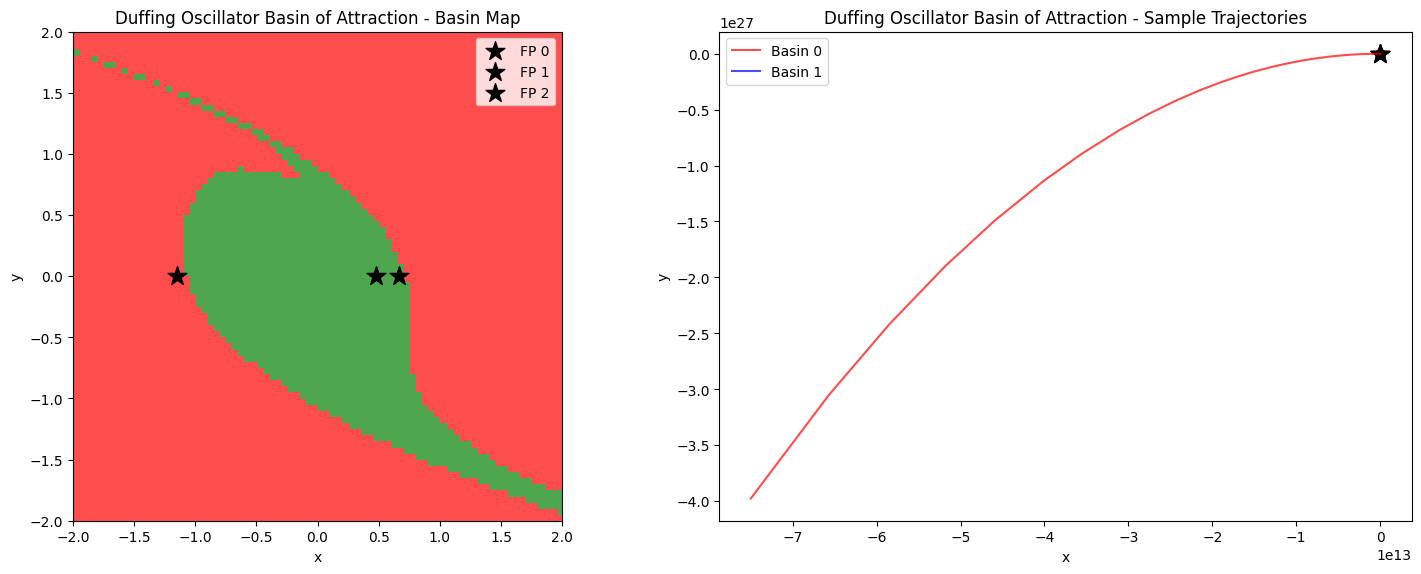


Plotting individual trajectories...


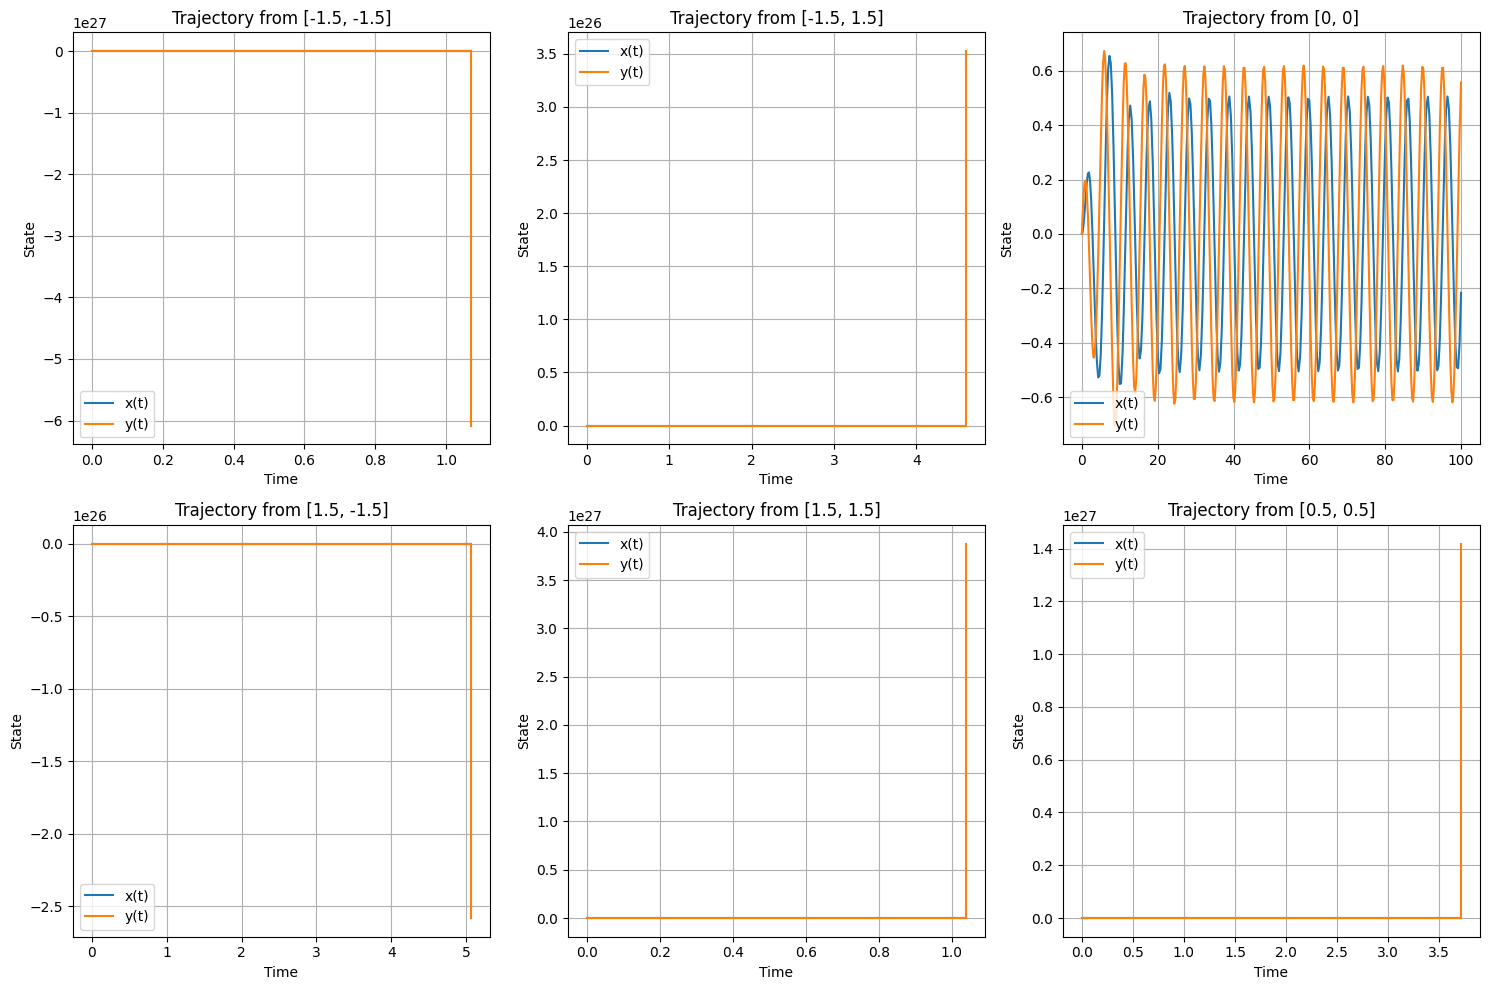


Additional Statistics:
Number of distinct basins: 2
Basin 0: 5040 points (78.8%)
Basin 1: 1360 points (21.2%)


In [1]:
# Cell 1: Install required packages
!pip install numpy scipy matplotlib plotly scikit-learn

# Cell 2: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors

# Cell 3: Define the dynamical system (replace with actual system from RCBasins)
def duffing_oscillator(t, state, alpha, beta, delta, gamma, omega):
    """
    Duffing oscillator example - replace with your specific system
    x'' + delta*x' + alpha*x + beta*x^3 = gamma*cos(omega*t)
    """
    x, y = state
    dxdt = y
    dydt = -delta*y - alpha*x - beta*x**3 + gamma*np.cos(omega*t)
    return [dxdt, dydt]

def lorenz_system(t, state, sigma, rho, beta):
    """
    Lorenz system as another example
    """
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Cell 4: Find fixed points
def find_fixed_points(system, bounds, params, grid_points=10):
    """
    Find fixed points of the system
    """
    def equations(state):
        return system(0, state, *params)

    fixed_points = []
    x_range = np.linspace(bounds[0], bounds[1], grid_points)
    y_range = np.linspace(bounds[2], bounds[3], grid_points)

    for x0 in x_range:
        for y0 in y_range:
            try:
                sol = fsolve(equations, [x0, y0], full_output=True)
                if sol[2] == 1:  # Solution found
                    fp = sol[0]
                    # Check if this is a new fixed point
                    is_new = True
                    for existing_fp in fixed_points:
                        if np.linalg.norm(fp - existing_fp) < 0.1:
                            is_new = False
                            break
                    if is_new:
                        fixed_points.append(fp)
            except:
                continue

    return np.array(fixed_points)

# Cell 5: Compute basin of attraction
def compute_basin(system, bounds, fixed_points, params, grid_size=50, integration_time=100):
    """
    Compute basin of attraction for the system
    """
    x_min, x_max, y_min, y_max = bounds
    X, Y = np.meshgrid(np.linspace(x_min, x_max, grid_size),
                      np.linspace(y_min, y_max, grid_size))

    basin = np.zeros(X.shape)

    for i in range(grid_size):
        for j in range(grid_size):
            initial_condition = [X[i,j], Y[i,j]]

            # Integrate the system
            try:
                sol = solve_ivp(system, [0, integration_time], initial_condition,
                              args=params, method='RK45', rtol=1e-6)

                if sol.y.shape[1] > 0:
                    final_state = sol.y[:,-1]

                    # Find which fixed point it converged to
                    min_dist = float('inf')
                    closest_fp = -1

                    for k, fp in enumerate(fixed_points):
                        dist = np.linalg.norm(final_state - fp)
                        if dist < min_dist:
                            min_dist = dist
                            closest_fp = k

                    basin[i,j] = closest_fp
            except:
                basin[i,j] = -1  # Integration failed

    return X, Y, basin

# Cell 6: Plot basin of attraction
def plot_basin(X, Y, basin, fixed_points, title="Basin of Attraction"):
    """
    Create a beautiful plot of the basin of attraction
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Create custom colormap
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    cmap = mcolors.ListedColormap(colors[:len(fixed_points)])

    # Plot basin
    im = ax1.imshow(basin.T, extent=[X.min(), X.max(), Y.min(), Y.max()],
                   origin='lower', cmap=cmap, alpha=0.7)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title(f'{title} - Basin Map')

    # Plot trajectories from different starting points
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title(f'{title} - Sample Trajectories')

    # Add some sample trajectories
    for color_idx in range(len(fixed_points)):
        # Find a starting point in this basin
        points_in_basin = np.argwhere(basin == color_idx)
        if len(points_in_basin) > 0:
            idx = points_in_basin[len(points_in_basin)//2]  # Take middle point
            x0, y0 = X[idx[0], idx[1]], Y[idx[0], idx[1]]

            # Integrate and plot trajectory
            sol = solve_ivp(duffing_oscillator, [0, 50], [x0, y0],
                          args=duffing_params, method='RK45', rtol=1e-6,
                          dense_output=True)

            ax2.plot(sol.y[0], sol.y[1], color=colors[color_idx], alpha=0.7,
                    label=f'Basin {color_idx}')
            ax2.scatter([x0], [y0], color=colors[color_idx], marker='o', s=50)

    # Plot fixed points
    for k, fp in enumerate(fixed_points):
        ax1.scatter(fp[0], fp[1], color='black', marker='*', s=200, label=f'FP {k}')
        ax2.scatter(fp[0], fp[1], color='black', marker='*', s=200)

    ax1.legend()
    ax2.legend()
    plt.tight_layout()
    plt.show()

# Cell 7: Interactive 3D plot (if using 3D system)
def plot_3d_basin(system, params, num_trajectories=20):
    """
    Create interactive 3D plot of trajectories
    """
    fig = go.Figure()

    # Generate random initial conditions
    np.random.seed(42)
    initial_conditions = np.random.uniform(-2, 2, (num_trajectories, 3))

    for i, ic in enumerate(initial_conditions):
        sol = solve_ivp(lorenz_system, [0, 50], ic, args=params,
                       method='RK45', rtol=1e-6)

        fig.add_trace(go.Scatter3d(
            x=sol.y[0], y=sol.y[1], z=sol.y[2],
            mode='lines',
            line=dict(width=4, color=plt.cm.viridis(i/num_trajectories)),
            name=f'Trajectory {i+1}'
        ))

    fig.update_layout(
        title='3D Phase Space Trajectories',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )
    fig.show()

# Cell 8: Main analysis function
def main_analysis():
    """
    Main function to run the basin of attraction analysis
    """
    print("Starting Basin of Attraction Analysis...")

    # Parameters for Duffing oscillator
    global duffing_params
    duffing_params = (1.0, -1.0, 0.3, 0.37, 1.2)  # alpha, beta, delta, gamma, omega

    # Define search bounds
    bounds = [-2, 2, -2, 2]

    print("Finding fixed points...")
    # Find fixed points
    fixed_points = find_fixed_points(duffing_oscillator, bounds, duffing_params)
    print(f"Found {len(fixed_points)} fixed points:")
    for i, fp in enumerate(fixed_points):
        print(f"FP {i}: {fp}")

    print("Computing basin of attraction...")
    # Compute basin
    X, Y, basin = compute_basin(duffing_oscillator, bounds, fixed_points, duffing_params, grid_size=80)

    print("Plotting results...")
    # Plot results
    plot_basin(X, Y, basin, fixed_points, "Duffing Oscillator Basin of Attraction")

    # Show some individual trajectories
    print("\nPlotting individual trajectories...")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    test_points = [[-1.5, -1.5], [-1.5, 1.5], [0, 0], [1.5, -1.5], [1.5, 1.5], [0.5, 0.5]]

    for idx, (ax, point) in enumerate(zip(axes, test_points)):
        sol = solve_ivp(duffing_oscillator, [0, 100], point, args=duffing_params,
                       method='RK45', rtol=1e-6)

        ax.plot(sol.t, sol.y[0], label='x(t)')
        ax.plot(sol.t, sol.y[1], label='y(t)')
        ax.set_xlabel('Time')
        ax.set_ylabel('State')
        ax.set_title(f'Trajectory from {point}')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

    return basin, fixed_points

# Cell 9: Run the analysis
if __name__ == "__main__":
    basin, fixed_points = main_analysis()

    # Additional analysis
    print("\nAdditional Statistics:")
    unique_basins = np.unique(basin[basin >= 0])
    print(f"Number of distinct basins: {len(unique_basins)}")

    for basin_id in unique_basins:
        basin_size = np.sum(basin == basin_id)
        total_points = np.sum(basin >= 0)
        percentage = (basin_size / total_points) * 100
        print(f"Basin {int(basin_id)}: {basin_size} points ({percentage:.1f}%)")

In [2]:
# Cell 10: Utility functions for more advanced analysis
def stability_analysis(system, fixed_points, params):
    """
    Perform linear stability analysis around fixed points
    """
    from scipy.linalg import eig

    def jacobian(state, system, params):
        """Numerical Jacobian computation"""
        eps = 1e-8
        n = len(state)
        jac = np.zeros((n, n))

        for i in range(n):
            state_plus = state.copy()
            state_minus = state.copy()
            state_plus[i] += eps
            state_minus[i] -= eps

            f_plus = system(0, state_plus, *params)
            f_minus = system(0, state_minus, *params)

            jac[:, i] = (np.array(f_plus) - np.array(f_minus)) / (2 * eps)

        return jac

    print("Stability Analysis:")
    for i, fp in enumerate(fixed_points):
        J = jacobian(fp, system, params)
        eigenvalues, eigenvectors = eig(J)

        print(f"\nFixed Point {i} at {fp}:")
        print(f"Eigenvalues: {eigenvalues}")

        # Determine stability
        max_real_part = np.max(np.real(eigenvalues))
        if max_real_part < 0:
            stability = "Stable"
        elif max_real_part > 0:
            stability = "Unstable"
        else:
            stability = "Center/Marginally Stable"

        print(f"Stability: {stability}")

# Cell 11: Run stability analysis
print("Performing stability analysis...")
stability_analysis(duffing_oscillator, fixed_points, duffing_params)

Performing stability analysis...
Stability Analysis:

Fixed Point 0 at [-1.14970504  0.        ]:
Eigenvalues: [ 1.57857311+0.j -1.87857311+0.j]
Stability: Unstable

Fixed Point 1 at [0.48193457 0.        ]:
Eigenvalues: [-0.15+0.52982752j -0.15-0.52982752j]
Stability: Stable

Fixed Point 2 at [ 6.67770464e-01 -1.14793322e-59]:
Eigenvalues: [ 0.45021011+0.j -0.75021011+0.j]
Stability: Unstable
